In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
#модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier 



In [2]:
df = pd.read_csv('train.csv')
x = df.drop(['id', 'Heart Disease'], axis=1)
hd_codding = {'Absence':0, 'Presence': 1}
y = df['Heart Disease'].map(hd_codding)

Проверка на дисбаланс классов

In [28]:
y.describe()

count    630000.000000
mean          0.448340
std           0.497324
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: Heart Disease, dtype: float64

In [ ]:
df

0         1
1         0
2         0
3         0
4         1
         ..
629995    0
629996    0
629997    1
629998    1
629999    0
Name: Heart Disease, Length: 630000, dtype: int64

Нормализация 

In [4]:
scaler = MinMaxScaler()
print(scaler.fit(x))
print(scaler.transform(x))
x = pd.DataFrame(scaler.transform(x))


MinMaxScaler()
[[0.60416667 1.         1.         ... 0.5        0.66666667 1.        ]
 [0.47916667 1.         0.         ... 0.         0.         0.        ]
 [0.5625     0.         0.33333333 ... 0.         0.         0.        ]
 ...
 [0.79166667 1.         1.         ... 0.         0.66666667 1.        ]
 [0.47916667 1.         1.         ... 0.         0.         0.75      ]
 [0.45833333 0.         0.33333333 ... 0.         0.         0.        ]]


Деление на трейн/тест

In [5]:
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=666)

Начнем с обычной логрегрессии

In [35]:
lr_model = LogisticRegression(max_iter=1000, random_state=666)

Теперь RandomForest

In [37]:
rf_model = RandomForestClassifier(n_estimators=1000, random_state=666)

XGB Classifier

In [39]:
xgb_model = XGBClassifier(n_estimators=1000, random_state=666)

DecisionTree

In [40]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=666)

Прогоним все модели и посчитаем метрики

In [ ]:
models = [lr_model, rf_model, xgb_model, dt_model]
metrics = pd.DataFrame(columns=['LogisticRegression', 'RandomForest', 'XGB', 'DecisionTree'])

,LogisticRegression,RandomForest,XGB,DecisionTree


In [45]:
for model in models:
    model.fit(x_train, y_train)

📊 МЕТРИКИ МОДЕЛЕЙ

LogisticRegression:
  Accuracy:  0.8837
  Precision: 0.8801
  Recall:    0.8578
  F1-score:  0.8688
  ROC-AUC:   0.9508

RandomForest:
  Accuracy:  0.8821
  Precision: 0.8731
  Recall:    0.8629
  F1-score:  0.8680
  ROC-AUC:   0.9488

XGB:
  Accuracy:  0.8854
  Precision: 0.8776
  Recall:    0.8654
  F1-score:  0.8715
  ROC-AUC:   0.9515

DecisionTree:
  Accuracy:  0.8622
  Precision: 0.8618
  Recall:    0.8255
  F1-score:  0.8433
  ROC-AUC:   0.9322

📋 Сводная таблица:
                    Accuracy  Precision  Recall  F1-score  ROC-AUC
LogisticRegression    0.8837     0.8801  0.8578    0.8688   0.9508
RandomForest          0.8821     0.8731  0.8629    0.8680   0.9488
XGB                   0.8854     0.8776  0.8654    0.8715   0.9515
DecisionTree          0.8622     0.8618  0.8255    0.8433   0.9322


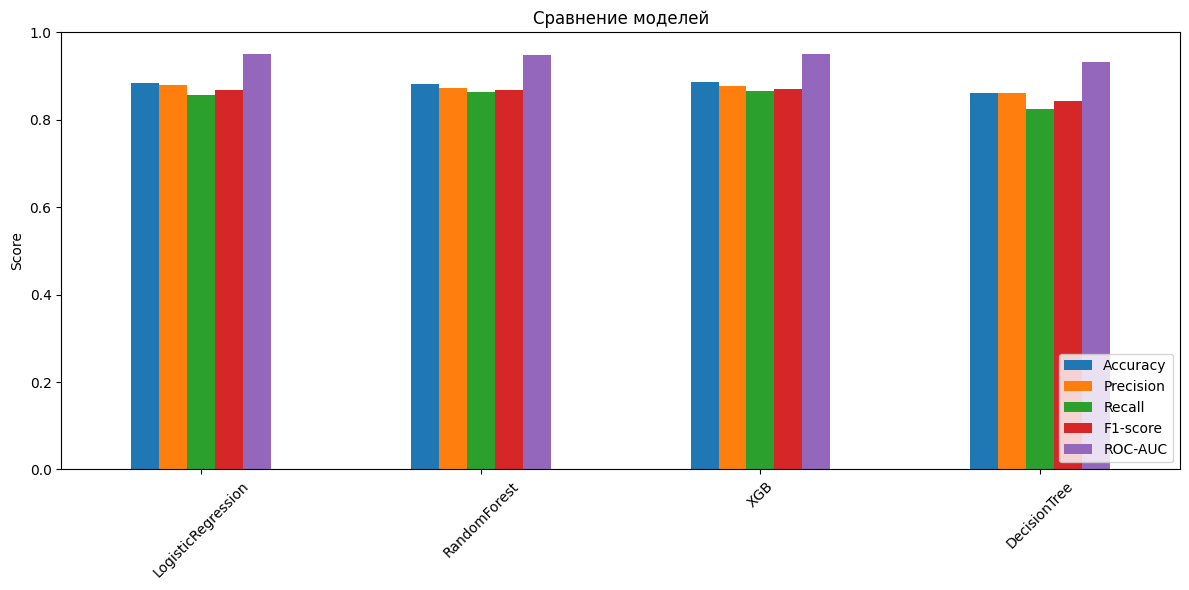

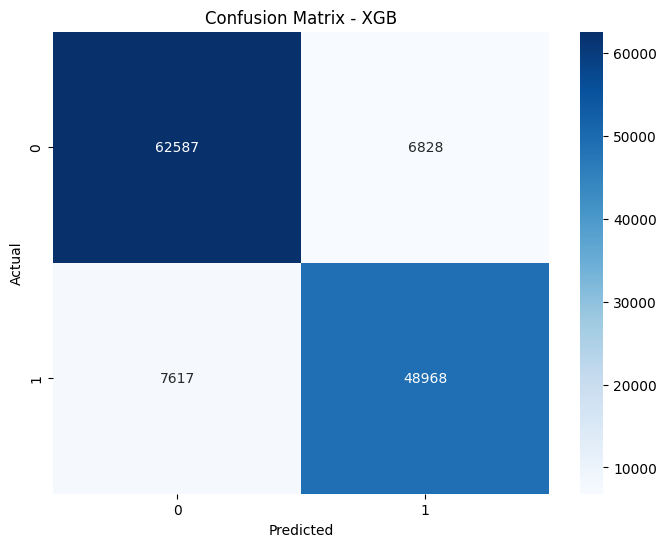

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns

# Список моделей и названий
models = [lr_model, rf_model, xgb_model, dt_model]
model_names = ['LogisticRegression', 'RandomForest', 'XGB', 'DecisionTree']

# Словарь для результатов
results = {}

print("📊 МЕТРИКИ МОДЕЛЕЙ")
print("="*60)

# Сбор метрик
for name, model in zip(model_names, models):
    y_pred = model.predict(x_valid)
    y_proba = model.predict_proba(x_valid)[:, 1]
    
    acc = accuracy_score(y_valid, y_pred)
    prec = precision_score(y_valid, y_pred)
    rec = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    roc_auc = roc_auc_score(y_valid, y_proba)
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 
        'Recall': rec, 'F1-score': f1, 'ROC-AUC': roc_auc
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

# DataFrame результатов
df_results = pd.DataFrame(results).T
print("\n📋 Сводная таблица:")
print(df_results.round(4).to_string())

# График
df_results.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение моделей')
plt.ylabel('Score')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Матрица ошибок для лучшей модели
best_model = df_results['F1-score'].idxmax()
best_idx = model_names.index(best_model)
y_pred_best = models[best_idx].predict(x_valid)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_valid, y_pred_best), 
            annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

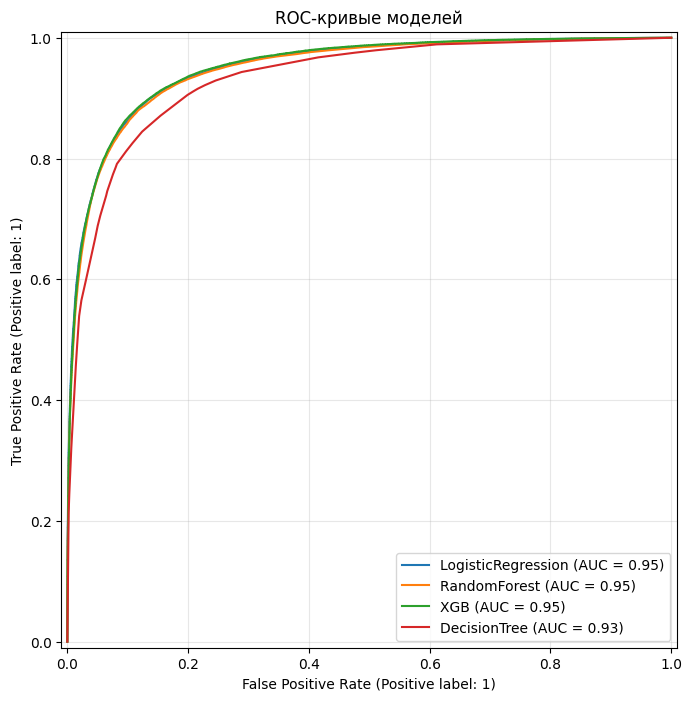

In [48]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in zip(model_names, models):
    RocCurveDisplay.from_estimator(model, x_valid, y_valid, ax=ax, name=name)

plt.title('ROC-кривые моделей')
plt.grid(alpha=0.3)
plt.show()

Будем двигаться по XGB(eXtreme Gradient Boosting) у него наибольший Roc-Auc(0.9515). Целевой - 0.954
Для начала попробуем побаловаться с гиперпараметрами.
Начнем с GridSearch(по сути просто перебор параметров)

In [6]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),        # больше деревьев
        'max_depth': trial.suggest_int('max_depth', 5, 12),                  # глубже деревья
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1, 2, 3]),
        'random_state': 666,
        'n_jobs': -1,
        'tree_method': 'hist',          # всё ещё быстро, но можно и 'approx'
    }
    
    model = XGBClassifier(**params)
    
    # Используем 5-фолд кросс-валидацию (было 3) – это увеличит время в ~1.7 раза
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=666)
    scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Создаём исследование
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=666)
)

# Запускаем с большим числом trials и таймаутом 3 часа (10800 сек)
study.optimize(objective, n_trials=200, timeout=10800, show_progress_bar=True)
print("Лучшие параметры:", study.best_params)
print("Лучший ROC-AUC на CV:", study.best_value)

[I 2026-02-20 20:10:33,811] A new study created in memory with name: no-name-23f4304e-b080-4eb1-ab25-bc781574dcd9
Best trial: 0. Best value: 0.953161:   0%|          | 1/200 [00:55<3:03:00, 55.18s/it, 55.18/10800 seconds]

[I 2026-02-20 20:11:28,991] Trial 0 finished with value: 0.9531606215162352 and parameters: {'n_estimators': 1201, 'max_depth': 11, 'learning_rate': 0.06064382076501895, 'subsample': 0.8639290286240374, 'colsample_bytree': 0.9757289787231697, 'min_child_weight': 1, 'gamma': 2.0679384939326173, 'reg_alpha': 0.24406396900000016, 'reg_lambda': 1.8993570518909029, 'scale_pos_weight': 3}. Best is trial 0 with value: 0.9531606215162352.


Best trial: 1. Best value: 0.955076:   1%|          | 2/200 [01:59<3:19:52, 60.57s/it, 119.52/10800 seconds]

[I 2026-02-20 20:12:33,334] Trial 1 finished with value: 0.955075763557842 and parameters: {'n_estimators': 693, 'max_depth': 10, 'learning_rate': 0.014748200090009479, 'subsample': 0.8872397271342943, 'colsample_bytree': 0.5025544193818999, 'min_child_weight': 2, 'gamma': 0.5547683599372333, 'reg_alpha': 1.2383411434751512, 'reg_lambda': 1.2091266931501352, 'scale_pos_weight': 1}. Best is trial 1 with value: 0.955075763557842.


Best trial: 1. Best value: 0.955076:   2%|▏         | 3/200 [03:18<3:46:33, 69.00s/it, 198.56/10800 seconds]

...

[I 2026-02-20 22:32:48,893] Trial 197 finished with value: 0.9553544172187524 and parameters: {'n_estimators': 718, 'max_depth': 5, 'learning_rate': 0.05645806785066163, 'subsample': 0.9669336247057566, 'colsample_bytree': 0.5274017332623742, 'min_child_weight': 1, 'gamma': 1.2498118594793246, 'reg_alpha': 4.037893068436653, 'reg_lambda': 7.287862031069026, 'scale_pos_weight': 3}. Best is trial 147 with value: 0.9553730506130874.


Best trial: 147. Best value: 0.955373: 100%|█████████▉| 199/200 [2:22:40<00:25, 25.34s/it, 8560.74/10800 seconds]

[I 2026-02-20 22:33:14,552] Trial 198 finished with value: 0.9553279894049711 and parameters: {'n_estimators': 718, 'max_depth': 5, 'learning_rate': 0.05984168596369278, 'subsample': 0.9676789579798133, 'colsample_bytree': 0.540278848993472, 'min_child_weight': 1, 'gamma': 1.1982741836711863, 'reg_alpha': 4.050445579912628, 'reg_lambda': 7.32256087063752, 'scale_pos_weight': 3}. Best is trial 147 with value: 0.9553730506130874.


Best trial: 147. Best value: 0.955373: 100%|██████████| 200/200 [2:23:09<00:00, 42.95s/it, 8589.84/10800 seconds]

[I 2026-02-20 22:33:43,647] Trial 199 finished with value: 0.9553520421228333 and parameters: {'n_estimators': 757, 'max_depth': 5, 'learning_rate': 0.05345435987299311, 'subsample': 0.9738658475218332, 'colsample_bytree': 0.5276835322604303, 'min_child_weight': 2, 'gamma': 0.11783462281290946, 'reg_alpha': 3.9651704374776977, 'reg_lambda': 6.856444940691185, 'scale_pos_weight': 3}. Best is trial 147 with value: 0.9553730506130874.
Лучшие параметры: {'n_estimators': 691, 'max_depth': 5, 'learning_rate': 0.07523249190518548, 'subsample': 0.9569350055297698, 'colsample_bytree': 0.5075926534237764, 'min_child_weight': 1, 'gamma': 1.2189384041730806, 'reg_alpha': 4.218975552256064, 'reg_lambda': 6.720253719904353, 'scale_pos_weight': 3}
Лучший ROC-AUC на CV: 0.9553730506130874


Лучшие параметры: {'n_estimators': 691, 'max_depth': 5, 'learning_rate': 0.07523249190518548, 'subsample': 0.9569350055297698, 'colsample_bytree': 0.5075926534237764, 'min_child_weight': 1, 'gamma': 1.2189384041730806, 'reg_alpha': 4.218975552256064, 'reg_lambda': 6.720253719904353, 'scale_pos_weight': 3}
Лучший ROC-AUC на CV: 0.9553730506130874